In [2]:
import wfdb
import os
import pandas as pd
from pathlib import Path

In [4]:
DATA_DIR = "data/QT_DB"   # adjust if needed

print("=== QT Database Explorer ===\n")

records = wfdb.get_record_list('qtdb')
print(f"Total records: {len(records)}\n")

# Example record
record_name = records[0]   # e.g., 'sel100'
print(f"=== Example Record: {record_name} ===")

record = wfdb.rdrecord(record_name, pn_dir='qtdb')
print(f"Sampling rate: {record.fs} Hz")
print(f"Duration: {record.sig_len / record.fs:.2f} seconds")
print(f"Number of channels: {record.n_sig}")
print(f"Channel names: {record.sig_name}")

=== QT Database Explorer ===

Total records: 105

=== Example Record: sel100 ===
Sampling rate: 250 Hz
Duration: 900.00 seconds
Number of channels: 2
Channel names: ['MLII', 'V5']


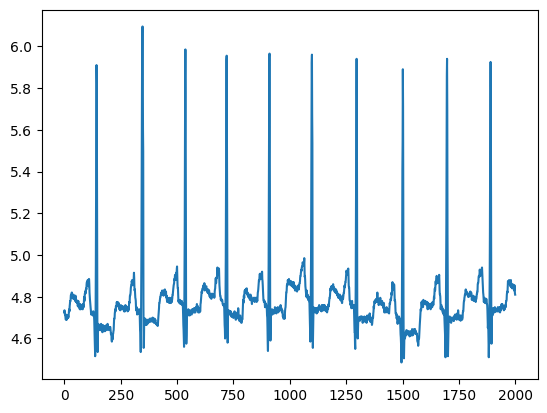

In [16]:
import matplotlib.pyplot as plt
plt.plot(record.p_signal.T[0][:2000])

In [10]:
# See the properties of record
print("\nRecord properties:")
for key, value in record.__dict__.items():
    if key != 'p_signal':  # skip the actual signal data for brevity
        print(f"{key}: {value}")


Record properties:
record_name: sel100
n_sig: 2
fs: 250
counter_freq: 360.0
base_counter: None
sig_len: 225000
base_time: None
base_date: None
comments: ['69 M 1085 1629 x1', 'Aldomet, Inderal', 'Produced by xform from record 100, beginning at 7:00.000']
sig_name: ['MLII', 'V5']
d_signal: None
e_p_signal: None
e_d_signal: None
file_name: ['sel100.dat', 'sel100.dat']
fmt: ['212', '212']
samps_per_frame: [1, 1]
skew: [None, None]
byte_offset: [None, None]
adc_gain: [200.0, 200.0]
baseline: [0, 0]
units: ['mV', 'mV']
adc_res: [11, 11]
adc_zero: [1024, 1024]
init_value: [945, 955]
checksum: [-13873, 14507]
block_size: [0, 0]


In [6]:
# Different annotation files available
print("\nAvailable annotation extensions:")
for ext in ['atr', 'man', 'qt1', 'q1c', 'pu']:
    try:
        ann = wfdb.rdann(record_name, ext, pn_dir='qtdb')
        print(f"  .{ext}: {len(ann.sample)} points | symbols: {set(ann.symbol)}")
    except:
        print(f"  .{ext}: Not available")

# Load reference delineation (usually .man or .q1c)
try:
    ann_ref = wfdb.rdann(record_name, 'man', pn_dir='qtdb')   # or 'q1c'
    print(f"\nReference annotations (.man): {len(ann_ref.sample)} points")
    print("Symbol distribution:")
    print(pd.Series(ann_ref.symbol).value_counts())
except:
    print("No .man annotations found for this record.")


Available annotation extensions:
  .atr: 1134 points | symbols: {'N', 'A'}
  .man: 30 points | symbols: {'N'}
  .qt1: 240 points | symbols: {'|', 'N'}
  .q1c: 240 points | symbols: {'t', 'N', ')', '(', 'p'}
  .pu: 21627 points | symbols: {'t', 'N', ')', '(', 'p'}

Reference annotations (.man): 30 points
Symbol distribution:
N    30
Name: count, dtype: int64
